<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/9_standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [70]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/Social_Network_Ads.csv")

In [71]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


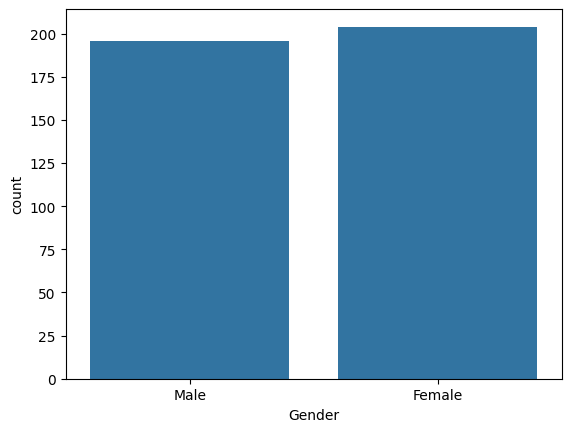

In [72]:
sns.countplot(x=df["Gender"])
plt.show()

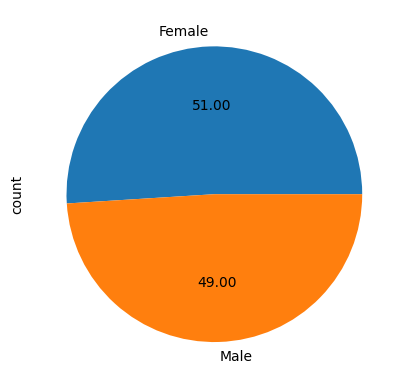

In [73]:
df["Gender"].value_counts().plot(kind="pie", autopct="%.2f")
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

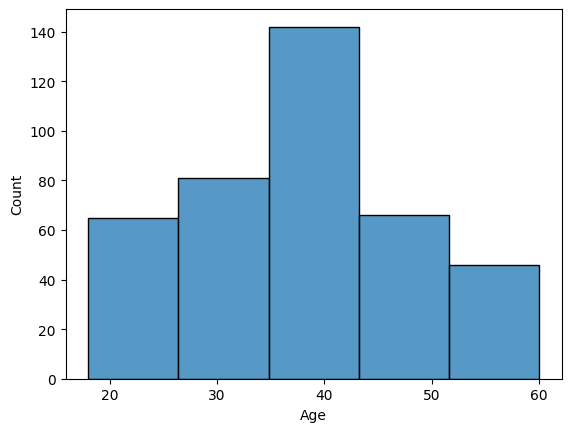

In [74]:
sns.histplot(x=df["Age"],bins=5)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

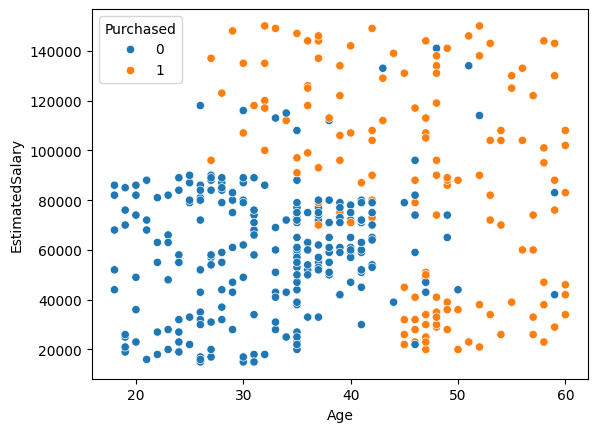

In [86]:
sns.scatterplot(x=df["Age"], y=df["EstimatedSalary"], hue="Purchased", data=df)


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [77]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


<Axes: xlabel='Purchased', ylabel='Age'>

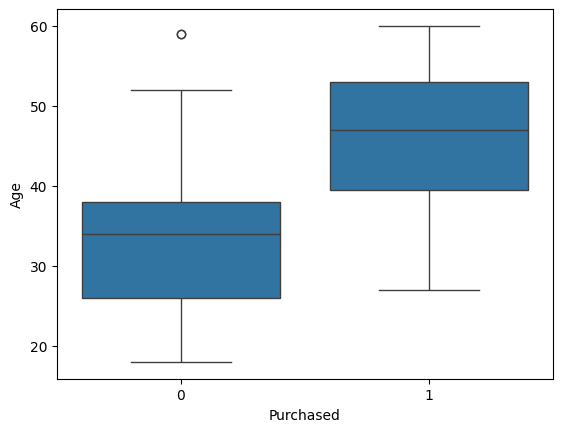

In [78]:
sns.boxplot(x=df["Purchased"],y=df["Age"])

<Axes: xlabel='Purchased', ylabel='Age'>

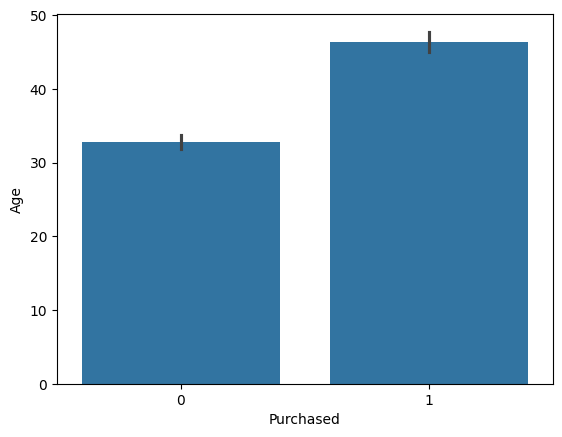

In [79]:
sns.barplot(x=df["Purchased"],y=df["Age"])

In [80]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [81]:
df=df.iloc[:,2:]

In [82]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [83]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [84]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [85]:
X_train.shape

(320, 2)

**StandardScaler**

In [90]:
scaller=StandardScaler()
scaller.fit(X_train)

StandardScaler()

In [92]:
X_train_scaled=scaller.transform(X_train)
X_test_scaled=scaller.transform(X_test)

In [95]:
scaller.mean_

array([3.8340625e+01, 7.1178125e+04])

In [97]:
X_train

,Age,EstimatedSalary
316,54,104000
55,24,55000
9,35,65000
123,35,53000
378,41,87000
...,...,...
337,35,79000
270,43,133000
178,24,23000
354,36,99000


In [103]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_train.columns)

In [104]:
X_train_scaled

,Age,EstimatedSalary
0,1.483571,0.966399
1,-1.358632,-0.476345
2,-0.316491,-0.181907
3,-0.316491,-0.535232
4,0.251949,0.465855
...,...,...
315,-0.316491,0.230305
316,0.441430,1.820268
317,-1.358632,-1.418544
318,-0.221751,0.819180


In [105]:
X_test_scaled

,Age,EstimatedSalary
0,-0.032271,1.231393
1,1.767791,-1.124107
2,0.251949,0.024199
3,0.251949,-0.770782
4,-1.169152,0.436412
...,...,...
75,-1.453372,-1.506876
76,-1.169152,0.377524
77,-1.548112,-0.240795
78,1.199350,-1.418544


In [107]:
X_train.describe()

,Age,EstimatedSalary
count,320.000000,320.000000
mean,38.340625,71178.125000
std,10.571724,34016.262332
min,18.000000,15000.000000
25%,30.000000,46750.000000
50%,37.500000,71000.000000
75%,46.000000,88250.000000
max,60.000000,150000.000000


In [112]:
np.round(X_train_scaled.describe(),2)

,Age,EstimatedSalary
count,320.00,320.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.93,-1.65
25%,-0.79,-0.72
50%,-0.08,-0.01
75%,0.73,0.50
max,2.05,2.32


**Effect of Scaling**

Text(0, 0.5, 'EstimatedSalary')

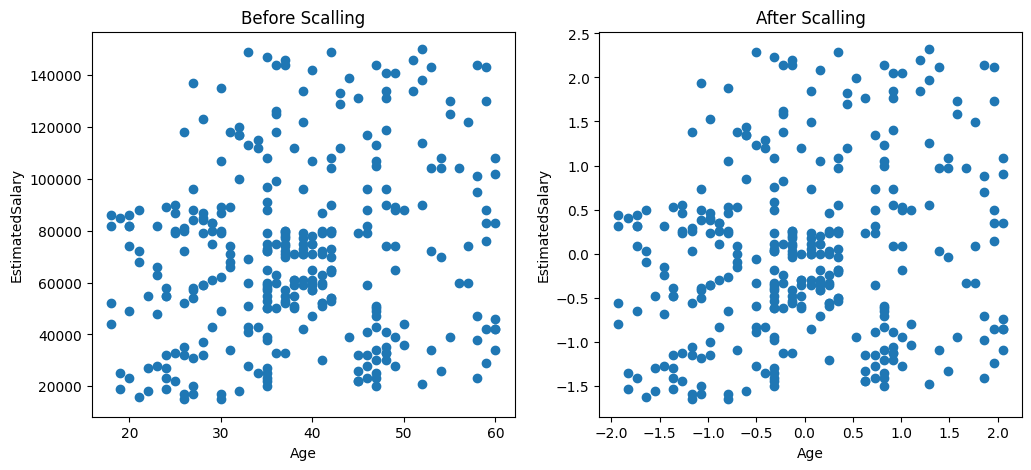

In [115]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Age"], X_train["EstimatedSalary"])
ax1.set_title("Before Scalling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"])
ax2.set_title("After Scalling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")

<Axes: title={'center': 'Before Scalling'}, xlabel='Age', ylabel='Density'>

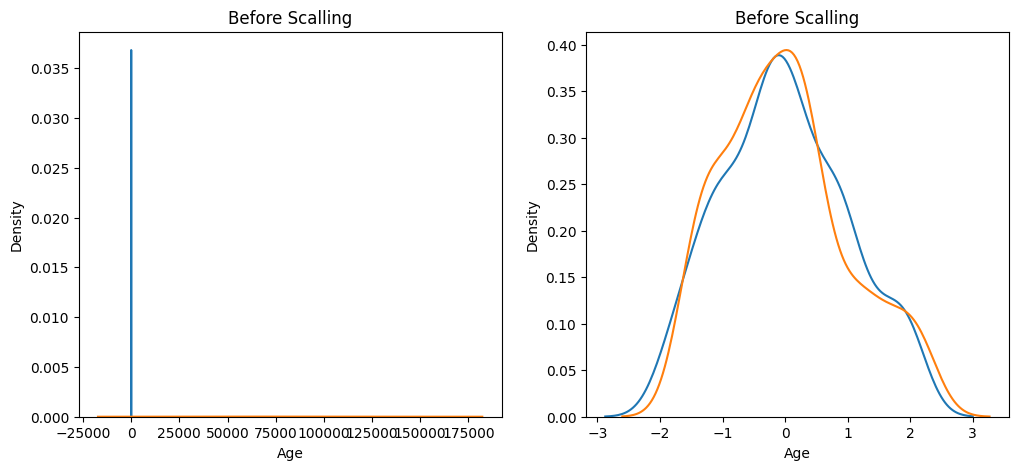

In [119]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x=X_train["Age"],ax=ax1)
sns.kdeplot(x=X_train["EstimatedSalary"],ax=ax1)


ax2.set_title("Before Scalling")
sns.kdeplot(x=X_train_scaled["Age"],ax=ax2)
sns.kdeplot(x=X_train_scaled["EstimatedSalary"],ax=ax2)


**Comparison of Distributions**

<Axes: title={'center': 'After  Scalling Age'}, xlabel='Age', ylabel='Density'>

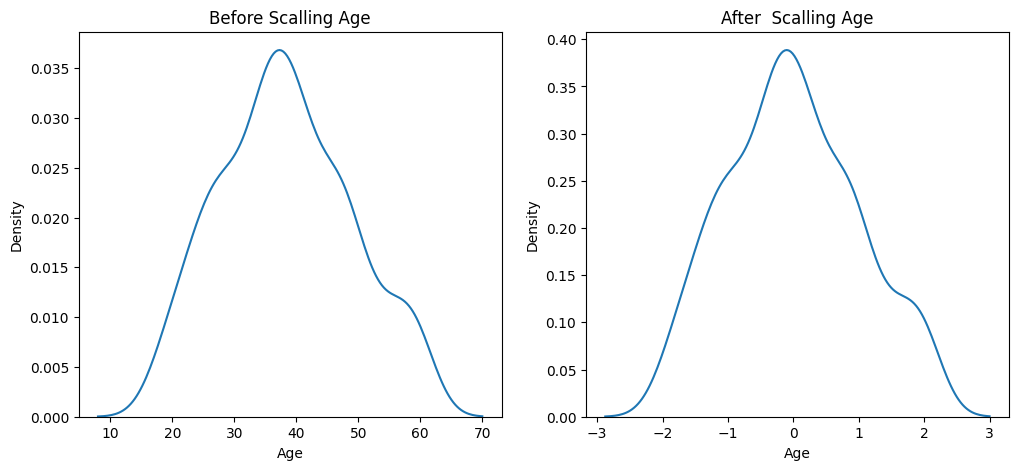

In [122]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling Age")
sns.kdeplot(x=X_train["Age"],ax=ax1)


ax2.set_title("After  Scalling Age")
sns.kdeplot(x=X_train_scaled["Age"],ax=ax2)


<Axes: title={'center': 'Before Scalling'}, xlabel='EstimatedSalary', ylabel='Density'>

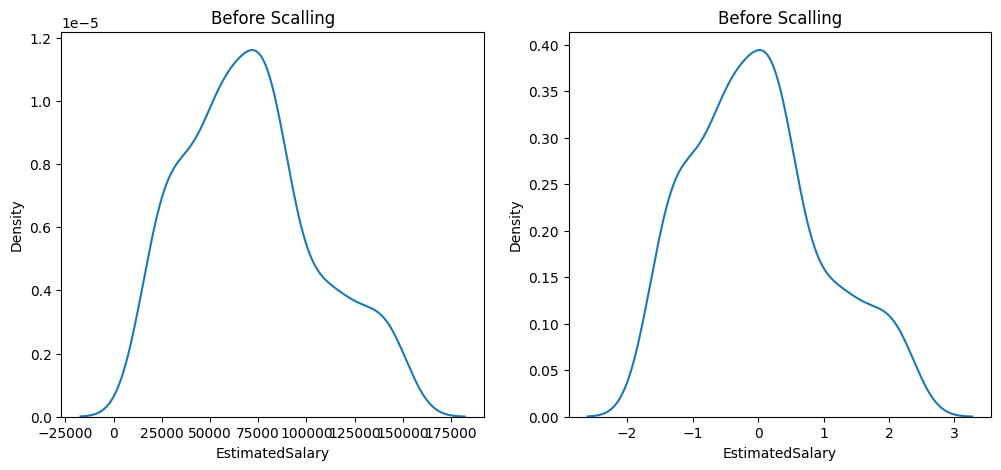

In [121]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling EstimatedSalary")
sns.kdeplot(x=X_train["EstimatedSalary"],ax=ax1)

ax2.set_title("After Scalling EstimatedSalary")
sns.kdeplot(x=X_train_scaled["EstimatedSalary"],ax=ax2)


Text(0, 0.5, 'EstimatedSalary')

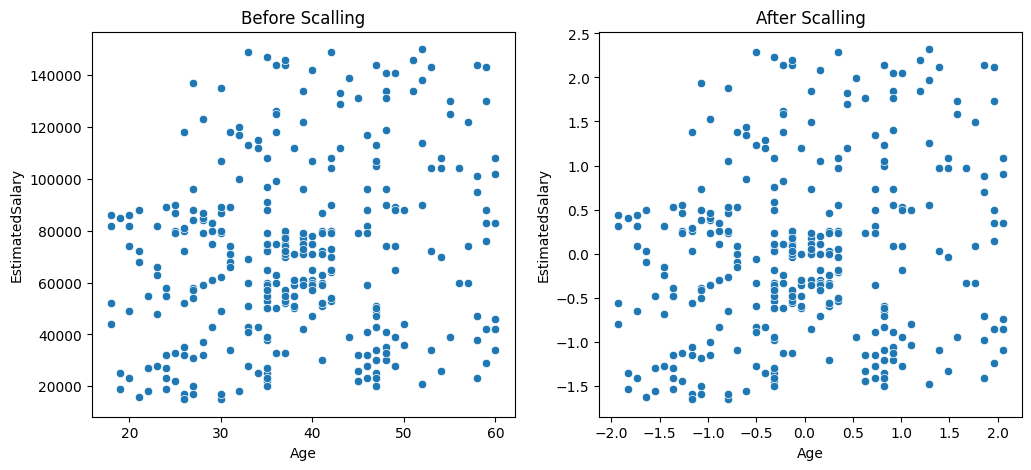

In [126]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.scatterplot(x=X_train["Age"], y=X_train["EstimatedSalary"],ax=ax1)
ax1.set_title("Before Scalling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

sns.scatterplot(x=X_train_scaled["Age"], y=X_train_scaled["EstimatedSalary"],ax=ax2)
ax2.set_title("After Scalling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")

**Why scaling is important?**